# 패키지 및 데이터

In [1]:
from hossam import *
from pandas import concat 
from pycaret.regression import *

In [2]:
origin = load_data("restaurant_sales_preprocessed")
origin.head()

어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)


,date,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
0,2024-01-01,16.169,122,14490,9.200,0.480,1.946,5.200,0,0
1,2024-01-02,16.005,106,11880,9.149,0.480,2.079,11.100,0,0
2,2024-01-03,16.354,120,18010,8.666,0.430,2.595,12.900,1,0
3,2024-01-04,16.082,115,11160,8.748,0.410,2.028,12.900,0,0
4,2024-01-05,16.113,124,15480,8.594,0.510,2.197,11.000,0,0


### 카테고리 변환

In [5]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("int")
origin["weekend"] = origin["weekend"].astype("int")
origin.info()



어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sales           353 non-null    float64
 1   visitors        353 non-null    int64  
 2   avg_price       353 non-null    int64  
 3   marketing_cost  353 non-null    float64
 4   delivery_ratio  353 non-null    float64
 5   rain_mm         353 non-null    float64
 6   temperature     353 non-null    float64
 7   holiday         353 non-null    int32  
 8   weekend         353 non-null    int32  
dtypes: float64(5), int32(2), int64(2)
memory usage: 24.8 KB


# Pycaret setup

### setup()

In [1]:
s = RegressionExperiment()
s.setup(data, target, **options)

NameError: name 'RegressionExperiment' is not defined

In [14]:
# ── Regression Experiment 생성
s = RegressionExperiment()

# ── 실험 환경 설정
s.setup(
    # ─────────────────────────────────
    # 기본 설정 (필수)
    # ─────────────────────────────────
    data=origin,                 # 데이터프레임
    target="sales",              # 예측 타깃
    session_id=52,               # 랜덤 시드 고정

    # ─────────────────────────────────
    # 데이터 분할
    # ─────────────────────────────────
    train_size=0.75,             # Train 비율
    fold=5,                      # CV fold 수

    # ─────────────────────────────────
    # 출력 / 성능 관련
    # ─────────────────────────────────
    verbose=False,               # 로그 출력 최소화
    use_gpu=False,             # GPU 사용 여부

    # ─────────────────────────────────
    # 전처리 설정 (1)
    # ─────────────────────────────────
    categorical_features=["weekend", "holiday"],
    ignore_features=[],

    normalize=True,              # 정규화 사용
    normalize_method="zscore",   # 'minmax', 'maxabs', 'robust', 'zscore'

    # ─────────────────────────────────
    # 전처리 설정 (2)
    # ─────────────────────────────────
    remove_outliers=False,       # 이상치 제거
    outliers_threshold=0.05,     # 이상치 비율 (사용 시)
    transform_target=False,      # 타깃 변환
    feature_selection=False,     # 변수 선택 자동화
)


In [15]:
s.pull()

,Description,Value
0,Session id,52
1,Target,sales
2,Target type,Regression
3,Original data shape,"(353, 9)"
4,Transformed data shape,"(353, 9)"
5,Transformed train set shape,"(264, 9)"
6,Transformed test set shape,"(89, 9)"
7,Numeric features,6
8,Categorical features,2
9,Preprocess,True


In [16]:
s.models

<bound method RegressionExperiment.models of <pycaret.regression.oop.RegressionExperiment object at 0x0000015D6808D310>>

### 기본 파라미터로 학습하기

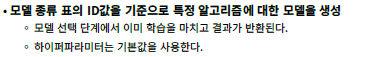

In [18]:
model = s.create_model("rf")
model

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1908,0.0553,0.2352,0.6325,0.0135,0.0116
1,0.1624,0.0444,0.2106,0.7492,0.0122,0.0100
2,0.1575,0.0390,0.1976,0.7546,0.0115,0.0097
3,0.1690,0.0441,0.2101,0.6170,0.0121,0.0104
4,0.1956,0.0642,0.2534,0.4657,0.0146,0.0119
Mean,0.1751,0.0494,0.2214,0.6438,0.0128,0.0107
Std,0.0154,0.0091,0.0201,0.1058,0.0011,0.0009


RandomForestRegressor(n_jobs=-1, random_state=52)

### 하이퍼파라미터 튜닝 학습 모델 생성

In [20]:
%%time

# ── 모델 하이퍼파라미터 튜닝
tuned = s.tune_model(
    estimator=model,
    optimize="RMSE",

    # ── 탐색 설정
    n_iter=30,
    fold=5,
    choose_better=True,
    early_stopping=True,

    # ── 출력 설정
    verbose=False,

    # ── 하이퍼파라미터 탐색 방식
    # grid = 전수 탐색 / random = 무작위 탐색
    search_algorithm="grid",

    # ── 사용자 정의 탐색 공간
    custom_grid={
        "n_estimators": [300, 500],          # ⭐ 성능 안정화
        "max_depth": [None, 10],             # ⭐ 과적합 제어
        "min_samples_leaf": [5, 10],         # ⭐ 과적합 방지 핵심
        "max_features": ["sqrt", 1.0],       # ⭐ 트리 다양성
    },
)

tuned


CPU times: total: 1.28 s
Wall time: 6.1 s


RandomForestRegressor(min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                      random_state=52)

### 하이퍼파라미터 확인

In [22]:
tuned.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 52,
 'verbose': 0,
 'warm_start': False}

### 결과 시각화

In [ ]:
s.evaluate_model(estimator=tuned)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### SHAP(summary)

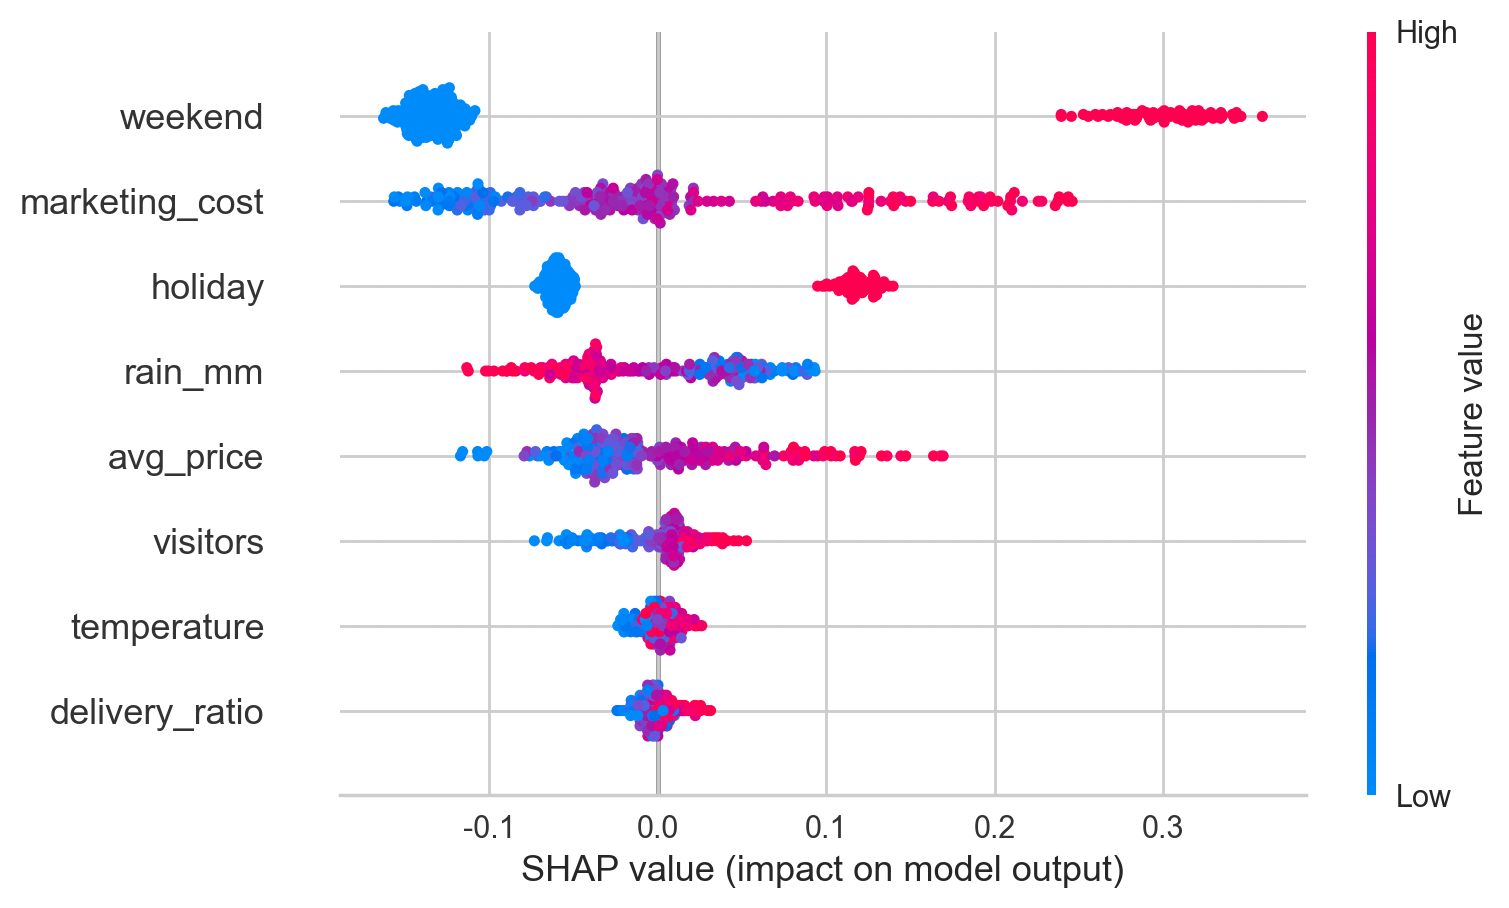

In [25]:
s.interpret_model(estimator=tuned, plot='summary', use_train_data=True)

### 변수간 관계 

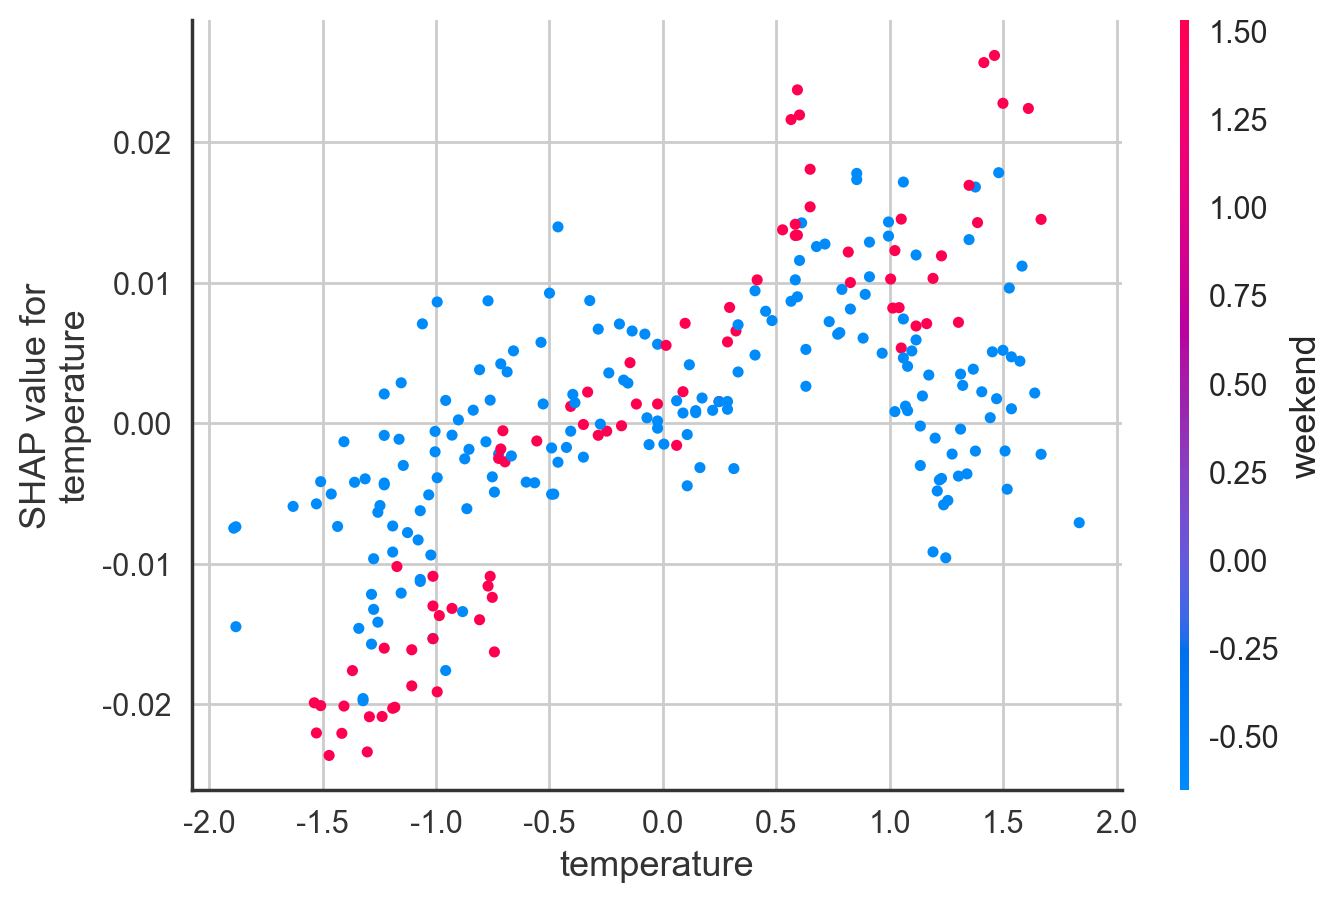

In [26]:
s.interpret_model(estimator=tuned, plot='correlation', use_train_data=True, feature='temperature')

### 각 데이터 추출

In [28]:
# ─────────────────────────────────
# 원본 독립변수 / 타깃 (분할 전)
# ─────────────────────────────────
X = s.get_config("X")
y = s.get_config("y")

# ─────────────────────────────────
# 훈련 데이터 (전처리 전)
# ─────────────────────────────────
X_train = s.get_config("X_train")
y_train = s.get_config("y_train")

# ─────────────────────────────────
# 테스트 데이터 (전처리 전)
# ─────────────────────────────────
X_test = s.get_config("X_test")
y_test = s.get_config("y_test")

# ─────────────────────────────────
# 훈련 데이터 (전처리 후)
# ─────────────────────────────────
X_train_transformed = s.get_config("X_train_transformed")
y_train_transformed = s.get_config("y_train_transformed")

# ─────────────────────────────────
# 테스트 데이터 (전처리 후)
# ─────────────────────────────────
X_test_transformed = s.get_config("X_test_transformed")
y_test_transformed = s.get_config("y_test_transformed")

# ─────────────────────────────────
# 전체 데이터 (전처리 후 결합)
# ─────────────────────────────────
X_transformed = concat([X_train_transformed, X_test_transformed])
y_transformed = concat([y_train_transformed, y_test_transformed])

# ─────────────────────────────────
# 데이터 크기 확인
# ─────────────────────────────────
(
    X.shape, y.shape,
    X_train.shape, y_train.shape,
    X_test.shape, y_test.shape,
    X_train_transformed.shape, y_train_transformed.shape,
    X_test_transformed.shape, y_test_transformed.shape,
    X_transformed.shape, y_transformed.shape,
)


((353, 8),
 (353,),
 (264, 8),
 (264,),
 (89, 8),
 (89,),
 (264, 8),
 (264,),
 (89, 8),
 (89,),
 (353, 8),
 (353,))

### 훈련데이터의 독립변수 원본 확인

In [30]:
X_train

,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
date,,,,,,,,
2024-06-11,129,8590,8.987,0.410,2.028,14.200,0,0
2024-06-20,115,22020,8.412,0.380,2.219,8.000,0,0
2024-08-25,115,14630,9.457,0.490,2.251,-2.900,1,1
2024-11-22,137,16830,8.810,0.380,1.194,0.700,0,0
2024-12-30,106,13370,8.537,0.480,2.197,9.600,0,0
...,...,...,...,...,...,...,...,...
2024-03-30,123,13930,7.901,0.530,2.015,27.700,1,1
2024-06-04,114,25370,8.700,0.510,1.589,11.400,0,0
2024-01-14,101,11620,8.319,0.210,0.916,12.900,1,1


# 성능평가

### 파이프라인 확인

In [33]:
pipeline = s.get_config('pipeline')
display(pipeline)

Pipeline(memory=FastMemory(location=C:\Users\itwill\AppData\Local\Temp\joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['visitors', 'avg_price',
                                             'marketing_cost', 'delivery_ratio',
                                             'rain_mm', 'temperature'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['weekend', 'holiday'],
                                    transformer=SimpleImputer(strat...
                 TransformerWrapper(include=['weekend', 'holiday'],
                                    transformer=OrdinalEncoder(cols=['weekend',
                                                                     'holiday'],
                                                               handle_missing='return_nan',
                                                               mapping=[{'col': 'weekend',
                                                                         'data_type': dtype('float64'),
                                                                         'mapping': 0.000    0
1.000    1
NaN     -1
dtype: int64},
                                                                        {'col': 'holiday',
                                                                         'data_type': dtype('float64'),
                                                                         'mapping': 0.000    0
1.000    1
NaN     -1
dtype: int64}]))),
                ('normalize',
                 TransformerWrapper(transformer=StandardScaler()))])

### 시각화 초기화

In [35]:
init_pyplot()


✅ 시각화를 위한 한글 글꼴(NotoSansKR-Regular)이 자동 적용되었습니다.


### 성능 평가 지표

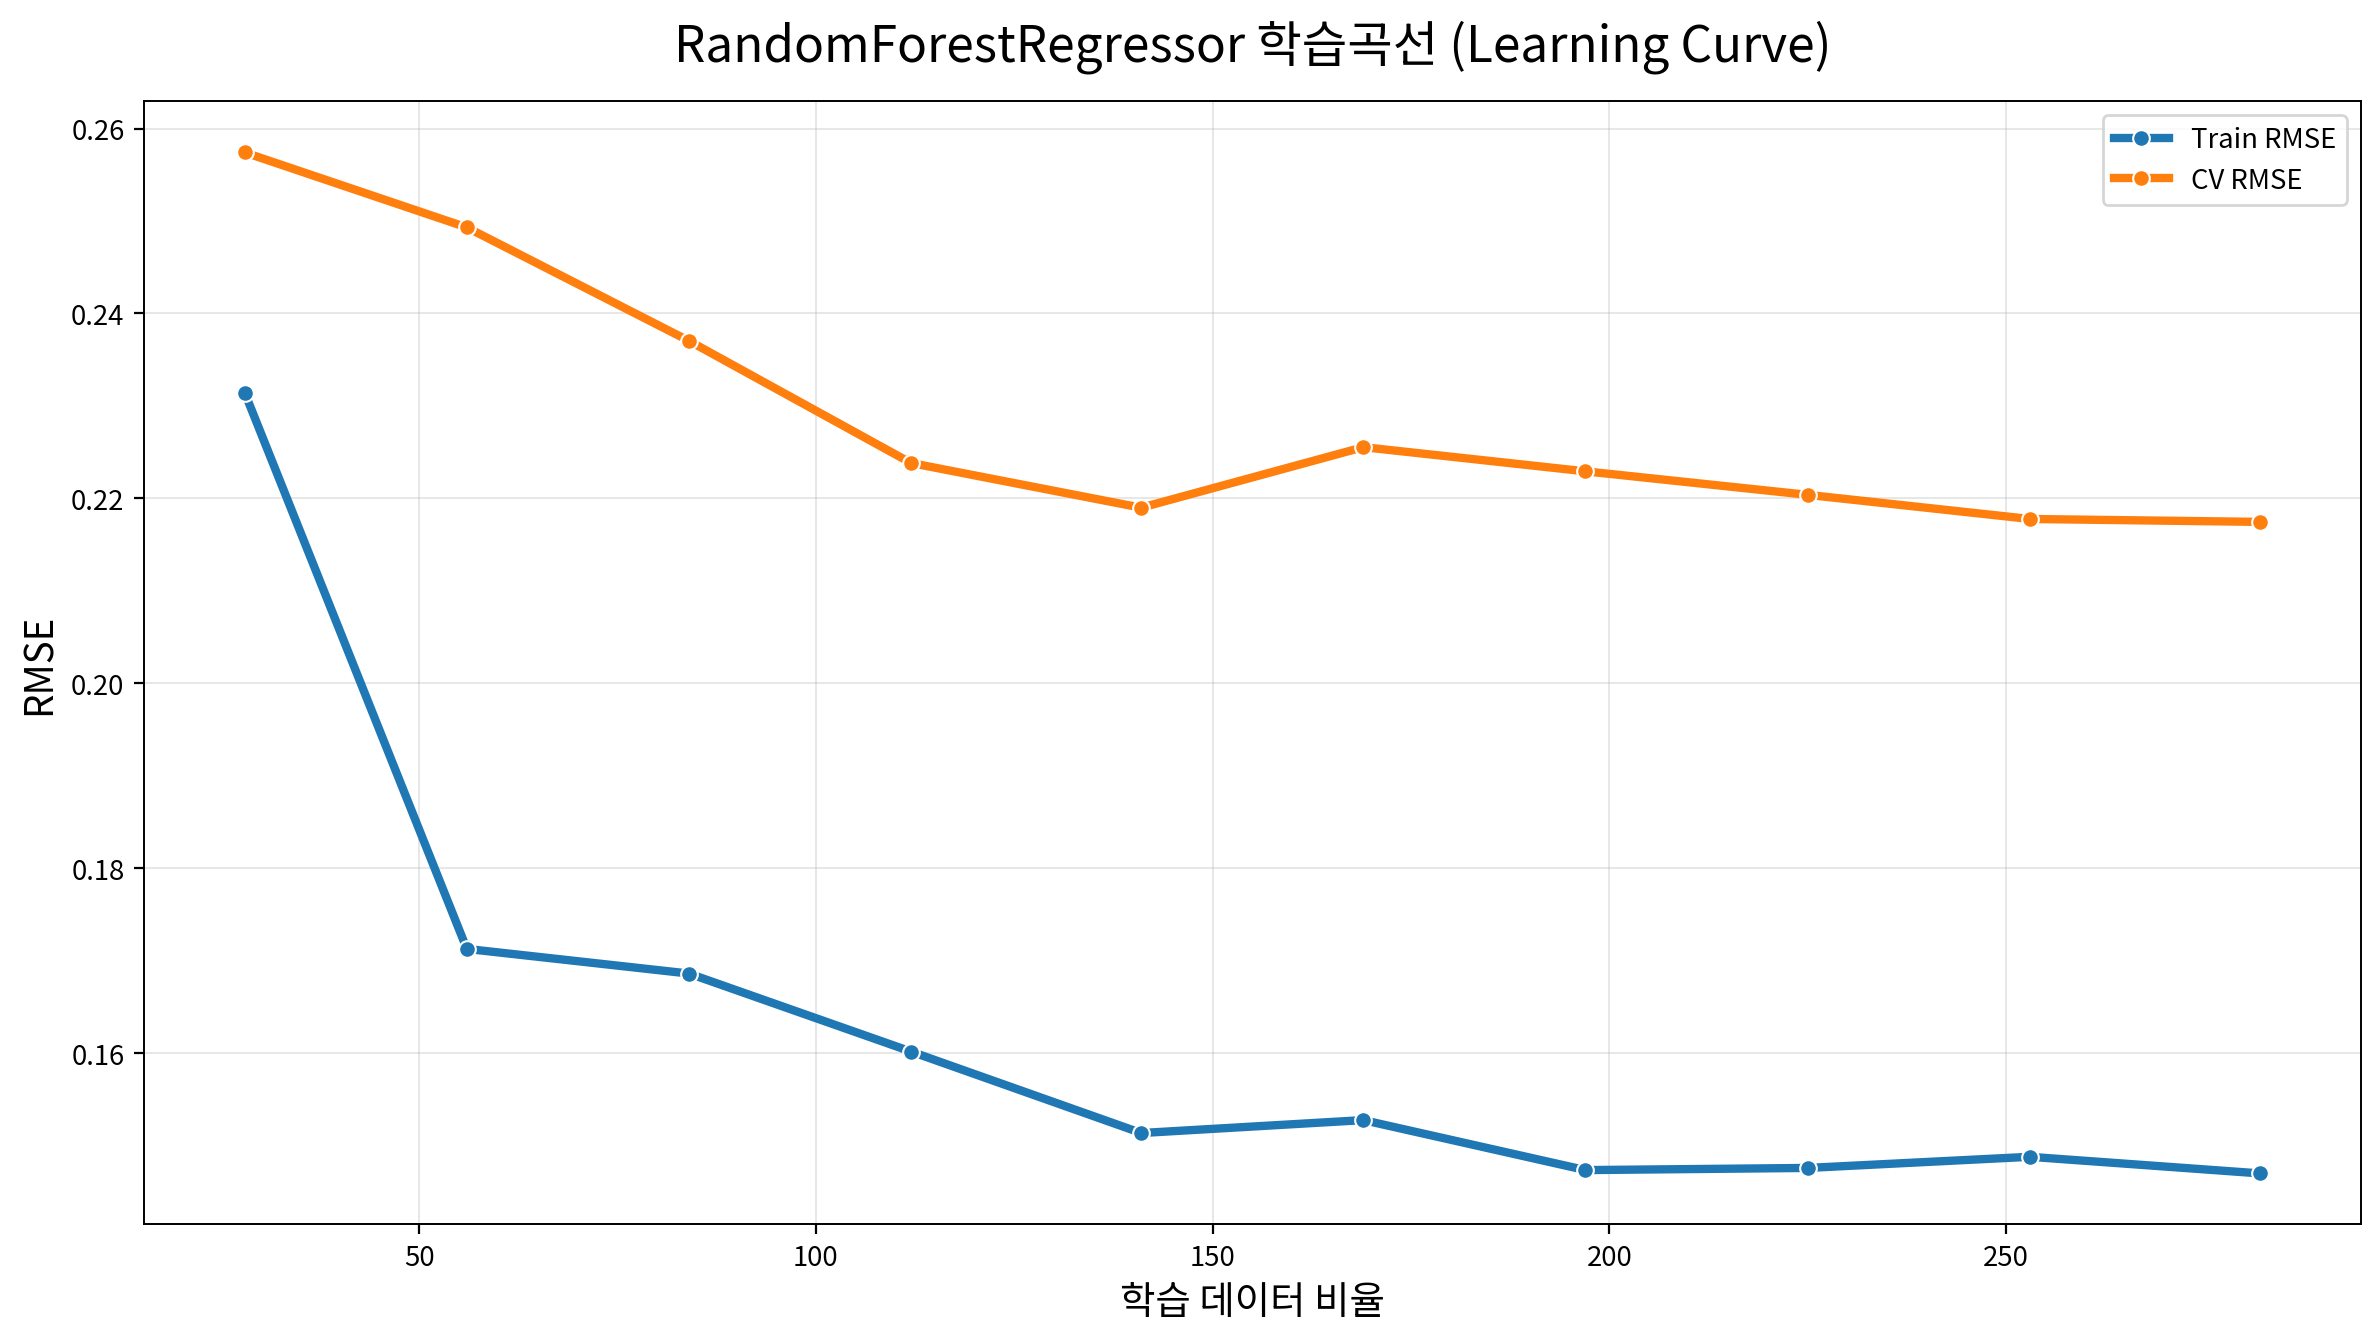

,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
RandomForestRegressor,0.678,0.168,0.046,0.215,0.010,0.302,0.147,0.217,0.013,0.676,0.062,⚠️ 과대적합


In [36]:
hs_get_score_cv(tuned, X_test_transformed, y_test_transformed, X_transformed, y_transformed)

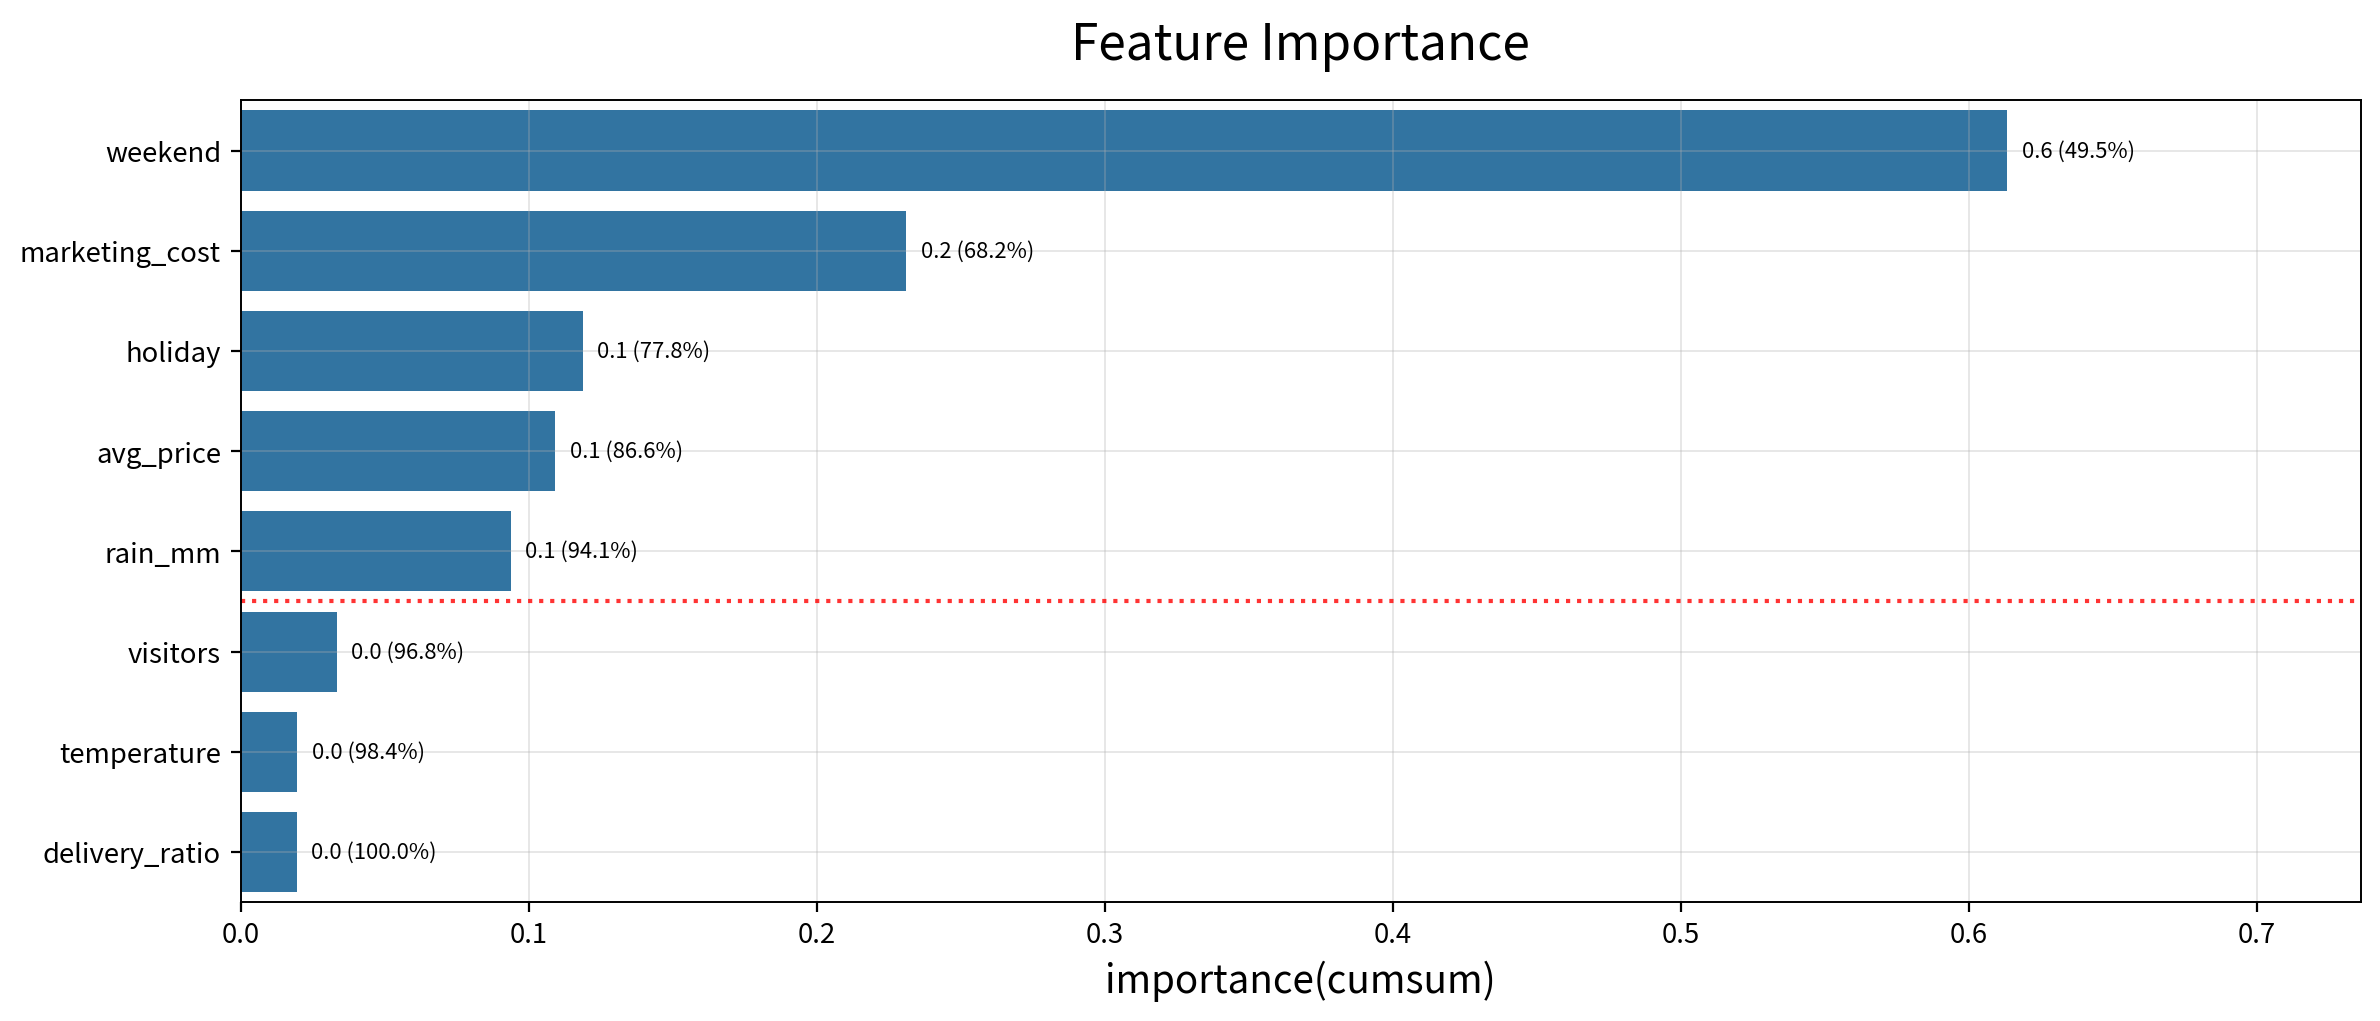

,importance,ratio,cumsum
weekend,0.613,0.495,0.495
marketing_cost,0.231,0.187,0.682
holiday,0.119,0.096,0.778
avg_price,0.109,0.088,0.866
rain_mm,0.094,0.076,0.941
visitors,0.033,0.027,0.968
temperature,0.020,0.016,0.984
delivery_ratio,0.020,0.016,1.000


In [39]:
hs_feature_importance(tuned, X_train_transformed, y_train_transformed)

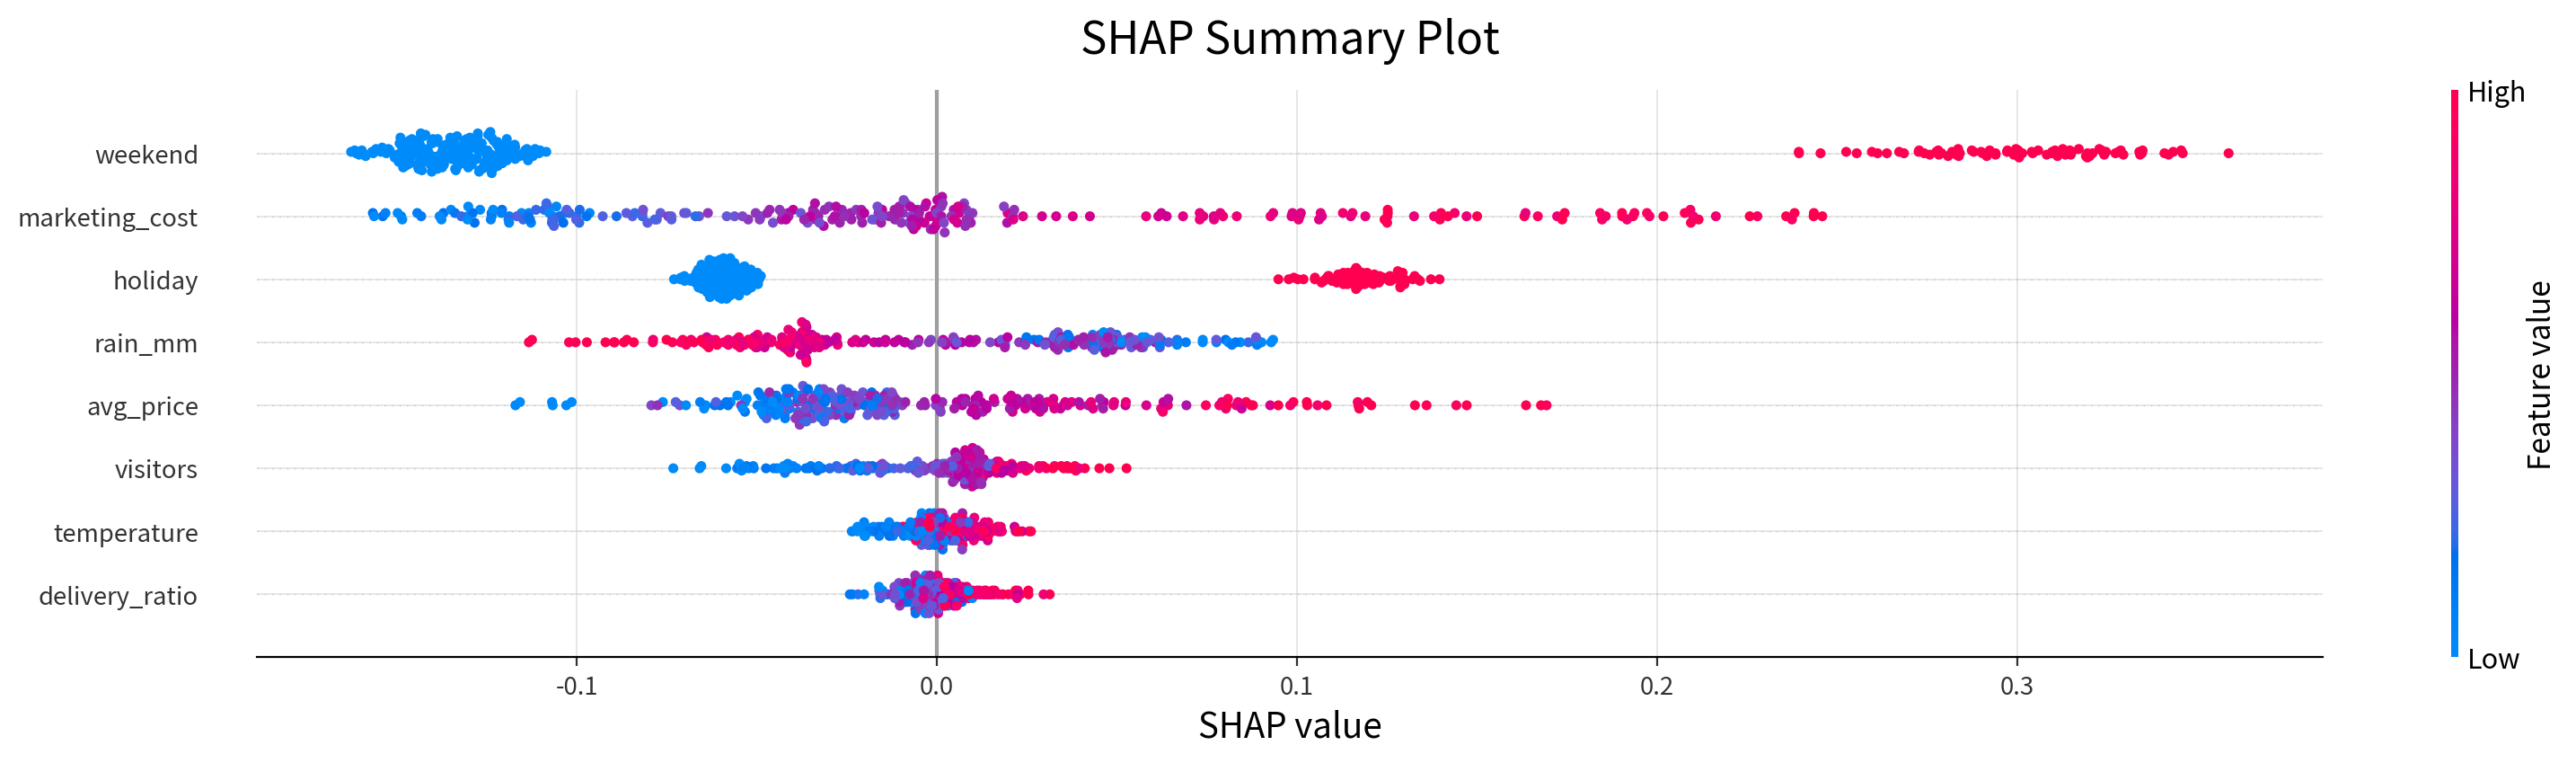

,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,variability,importance_ratio,importance_cumsum,is_important
0,weekend,0.184,-0.004,0.200,음(-) 경향,1.088,variable,0.395,0.395,core
1,marketing_cost,0.081,0.001,0.104,양(+) 경향,1.277,variable,0.174,0.569,core
2,holiday,0.080,0.003,0.085,양(+) 경향,1.065,variable,0.171,0.740,core
3,rain_mm,0.046,-0.001,0.051,음(-) 경향,1.113,variable,0.098,0.838,secondary
4,avg_price,0.043,-0.002,0.054,음(-) 경향,1.252,variable,0.092,0.930,secondary
5,visitors,0.018,0.000,0.023,양(+) 경향,1.301,variable,0.038,0.969,secondary
6,temperature,0.008,0.000,0.010,양(+) 경향,1.292,variable,0.017,0.985,secondary
7,delivery_ratio,0.007,-0.000,0.009,음(-) 경향,1.330,variable,0.015,1.000,secondary


In [41]:
df, v = hs_shap_analysis(tuned, X_train_transformed, width=1600)
df